# Recommender Sweep Analysis

This notebook loads recommender sweep outputs from `sweep_results/recommender`, finds the best configuration, and plots how each hyperparameter affects the selected metric.


In [4]:
from pathlib import Path
import json

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd

plt.style.use("ggplot")
pd.set_option("display.max_columns", 200)
pd.set_option("display.max_colwidth", 120)


In [5]:
SWEEP_ROOT = Path("../sweep_results/recommender")
RUN_ID_FILTER = None
SWEEP_BATCH_FILTER = None
PRIMARY_METRIC = "spearman_at_8"
TOP_N = 10

print(f"Sweep root: {SWEEP_ROOT.resolve()}")
print(f"Run filter: {RUN_ID_FILTER}")
print(f"Batch filter: {SWEEP_BATCH_FILTER}")
print(f"Primary metric: {PRIMARY_METRIC}")


Sweep root: /gpfs/helios/home/kelemnegasi/fed-xai/fed-perso-xai/sweep_results/recommender
Run filter: None
Batch filter: None
Primary metric: spearman_at_8


In [6]:
def load_sweep_trials(sweep_root: Path, run_id_filter=None, batch_filter=None) -> pd.DataFrame:
    records = []
    for config_path in sorted(sweep_root.glob("**/config.json")):
        trial_dir = config_path.parent
        metrics_path = trial_dir / "metrics_summary.json"
        if not metrics_path.exists():
            continue

        with config_path.open("r", encoding="utf-8") as f:
            config = json.load(f)
        with metrics_path.open("r", encoding="utf-8") as f:
            metrics = json.load(f)

        run_id = config["run_id"]
        batch_id = config["sweep_batch_id"]
        if run_id_filter and run_id != run_id_filter:
            continue
        if batch_filter and batch_id != batch_filter:
            continue

        hyper = config.get("hyperparameters", {})
        aggregate = metrics.get("aggregate", {})
        client_metrics = metrics.get("clients", {})
        client_spearman = {
            client_id: values.get("spearman")
            for client_id, values in client_metrics.items()
        }

        record = {
            "run_id": run_id,
            "sweep_batch_id": batch_id,
            "trial_id": config.get("trial_id"),
            "mode": config.get("mode"),
            "selection_id": config.get("selection_id"),
            "persona_assignment_policy": config.get("persona_assignment_policy"),
            "fixed_persona": config.get("fixed_persona"),
            "persona_assignment_alpha": config.get("persona_assignment_alpha"),
            "label_namespace": config.get("label_namespace"),
            "train_rounds": hyper.get("train_rounds"),
            "train_epochs": hyper.get("train_epochs"),
            "train_batch_size": hyper.get("train_batch_size"),
            "train_learning_rate": hyper.get("train_learning_rate"),
            "train_svm_c": hyper.get("train_svm_c"),
            "train_svm_intercept_scaling": hyper.get("train_svm_intercept_scaling"),
            "spearman_at_3": aggregate.get("spearman_at_3"),
            "spearman_at_5": aggregate.get("spearman_at_5"),
            "spearman_at_8": aggregate.get("spearman_at_8"),
            "mean_client_spearman": (
                float(np.mean(list(client_spearman.values()))) if client_spearman else np.nan
            ),
            "std_client_spearman": (
                float(np.std(list(client_spearman.values()))) if client_spearman else np.nan
            ),
            "client_spearman": client_spearman,
            "trial_dir": config.get("paths", {}).get("trial_dir"),
            "evaluation_summary_path": config.get("paths", {}).get("evaluation_summary"),
            "metrics_summary_path": config.get("paths", {}).get("metrics_summary"),
        }
        records.append(record)

    if not records:
        return pd.DataFrame()

    df = pd.DataFrame.from_records(records)
    df = df.sort_values(
        by=[PRIMARY_METRIC, "spearman_at_5", "spearman_at_3"],
        ascending=False,
    ).reset_index(drop=True)
    return df


df = load_sweep_trials(SWEEP_ROOT, RUN_ID_FILTER, SWEEP_BATCH_FILTER)
print(f"Loaded {len(df)} completed trials")
df.head(3)


Loaded 48 completed trials


,run_id,sweep_batch_id,trial_id,mode,selection_id,persona_assignment_policy,fixed_persona,persona_assignment_alpha,label_namespace,train_rounds,train_epochs,train_batch_size,train_learning_rate,train_svm_c,train_svm_intercept_scaling,spearman_at_3,spearman_at_5,spearman_at_8,mean_client_spearman,std_client_spearman,client_spearman,trial_dir,evaluation_summary_path,metrics_summary_path
0,federated-training-cencus_income-20260505t201144701891+0000-logreg-15clients-alpha0.3-seed42-cbf1f302be03,20260512t183906-2324800,lr-0p01__c-5p0__rounds-100__epochs-3,plain,test__max-40__seed-42,fixed,lay,None,lay__20260512t183906-2324800__lr-0p01__c-5p0__rounds-100__epochs-3,100,3,2048,0.010,5.0,1.0,0.595571,0.751784,0.900105,0.791498,0.092349,"{'client_000': 0.7573676325918922, 'client_001': 0.6393436107869097, 'client_002': 0.7636713152831147, 'client_003':...",sweep_results/recommender/federated-training-cencus_income-20260505t201144701891+0000-logreg-15clients-alpha0.3-seed...,sweep_results/recommender/federated-training-cencus_income-20260505t201144701891+0000-logreg-15clients-alpha0.3-seed...,sweep_results/recommender/federated-training-cencus_income-20260505t201144701891+0000-logreg-15clients-alpha0.3-seed...
1,federated-training-cencus_income-20260505t201144701891+0000-logreg-15clients-alpha0.3-seed42-cbf1f302be03,20260512t183906-2324800,lr-0p01__c-5p0__rounds-200__epochs-3,plain,test__max-40__seed-42,fixed,lay,None,lay__20260512t183906-2324800__lr-0p01__c-5p0__rounds-200__epochs-3,200,3,2048,0.010,5.0,1.0,0.596382,0.753104,0.900087,0.791555,0.093038,"{'client_000': 0.7570603193370519, 'client_001': 0.6406788224313997, 'client_002': 0.7652223536488816, 'client_003':...",sweep_results/recommender/federated-training-cencus_income-20260505t201144701891+0000-logreg-15clients-alpha0.3-seed...,sweep_results/recommender/federated-training-cencus_income-20260505t201144701891+0000-logreg-15clients-alpha0.3-seed...,sweep_results/recommender/federated-training-cencus_income-20260505t201144701891+0000-logreg-15clients-alpha0.3-seed...
2,federated-training-cencus_income-20260505t201144701891+0000-logreg-15clients-alpha0.3-seed42-cbf1f302be03,20260512t183906-2324800,lr-0p005__c-5p0__rounds-200__epochs-5,plain,test__max-40__seed-42,fixed,lay,None,lay__20260512t183906-2324800__lr-0p005__c-5p0__rounds-200__epochs-5,200,5,2048,0.005,5.0,1.0,0.599831,0.751801,0.900086,0.789912,0.092846,"{'client_000': 0.7534838848961257, 'client_001': 0.6417438352489899, 'client_002': 0.7652958552212539, 'client_003':...",sweep_results/recommender/federated-training-cencus_income-20260505t201144701891+0000-logreg-15clients-alpha0.3-seed...,sweep_results/recommender/federated-training-cencus_income-20260505t201144701891+0000-logreg-15clients-alpha0.3-seed...,sweep_results/recommender/federated-training-cencus_income-20260505t201144701891+0000-logreg-15clients-alpha0.3-seed...


In [7]:
if df.empty:
    raise RuntimeError("No completed sweep trials were found for the current filters.")

summary_columns = [
    "run_id",
    "sweep_batch_id",
    "trial_id",
    "mode",
    "fixed_persona",
    "train_learning_rate",
    "train_svm_c",
    "train_rounds",
    "train_epochs",
    "spearman_at_3",
    "spearman_at_5",
    "spearman_at_8",
    "mean_client_spearman",
]

best_row = df.iloc[0]
display(df[summary_columns].head(TOP_N))

print("Best configuration")
display(best_row[summary_columns])


,run_id,sweep_batch_id,trial_id,mode,fixed_persona,train_learning_rate,train_svm_c,train_rounds,train_epochs,spearman_at_3,spearman_at_5,spearman_at_8,mean_client_spearman
0,federated-training-cencus_income-20260505t201144701891+0000-logreg-15clients-alpha0.3-seed42-cbf1f302be03,20260512t183906-2324800,lr-0p01__c-5p0__rounds-100__epochs-3,plain,lay,0.010,5.0,100,3,0.595571,0.751784,0.900105,0.791498
1,federated-training-cencus_income-20260505t201144701891+0000-logreg-15clients-alpha0.3-seed42-cbf1f302be03,20260512t183906-2324800,lr-0p01__c-5p0__rounds-200__epochs-3,plain,lay,0.010,5.0,200,3,0.596382,0.753104,0.900087,0.791555
2,federated-training-cencus_income-20260505t201144701891+0000-logreg-15clients-alpha0.3-seed42-cbf1f302be03,20260512t183906-2324800,lr-0p005__c-5p0__rounds-200__epochs-5,plain,lay,0.005,5.0,200,5,0.599831,0.751801,0.900086,0.789912
3,federated-training-cencus_income-20260505t201144701891+0000-logreg-15clients-alpha0.3-seed42-cbf1f302be03,20260512t183906-2324800,lr-0p005__c-5p0__rounds-100__epochs-5,plain,lay,0.005,5.0,100,5,0.595735,0.751725,0.900002,0.789903
4,federated-training-cencus_income-20260505t201144701891+0000-logreg-15clients-alpha0.3-seed42-cbf1f302be03,20260512t183906-2324800,lr-0p02__c-1p0__rounds-200__epochs-5,plain,lay,0.020,1.0,200,5,0.596560,0.752224,0.899865,0.789756
5,federated-training-cencus_income-20260505t201144701891+0000-logreg-15clients-alpha0.3-seed42-cbf1f302be03,20260512t183906-2324800,lr-0p02__c-5p0__rounds-100__epochs-3,plain,lay,0.020,5.0,100,3,0.604559,0.750001,0.899840,0.791426
6,federated-training-cencus_income-20260505t201144701891+0000-logreg-15clients-alpha0.3-seed42-cbf1f302be03,20260512t183906-2324800,lr-0p02__c-1p0__rounds-100__epochs-3,plain,lay,0.020,1.0,100,3,0.582490,0.748450,0.899511,0.790325
7,federated-training-cencus_income-20260505t201144701891+0000-logreg-15clients-alpha0.3-seed42-cbf1f302be03,20260512t183906-2324800,lr-0p01__c-5p0__rounds-200__epochs-5,plain,lay,0.010,5.0,200,5,0.600624,0.749846,0.899129,0.790285
8,federated-training-cencus_income-20260505t201144701891+0000-logreg-15clients-alpha0.3-seed42-cbf1f302be03,20260512t183906-2324800,lr-0p01__c-5p0__rounds-100__epochs-5,plain,lay,0.010,5.0,100,5,0.596401,0.750052,0.899099,0.791029
9,federated-training-cencus_income-20260505t201144701891+0000-logreg-15clients-alpha0.3-seed42-cbf1f302be03,20260512t183906-2324800,lr-0p02__c-1p0__rounds-100__epochs-5,plain,lay,0.020,1.0,100,5,0.595383,0.751967,0.898875,0.790206


Best configuration


run_id                  federated-training-cencus_income-20260505t201144701891+0000-logreg-15clients-alpha0.3-seed42-cbf1f302be03
sweep_batch_id                                                                                            20260512t183906-2324800
trial_id                                                                                     lr-0p01__c-5p0__rounds-100__epochs-3
mode                                                                                                                        plain
fixed_persona                                                                                                                 lay
train_learning_rate                                                                                                          0.01
train_svm_c                                                                                                                   5.0
train_rounds                                                                              

,client_id,spearman
0,client_012,0.928942
1,client_008,0.917757
2,client_011,0.868019
3,client_013,0.862503
4,client_009,0.851415
5,client_007,0.839950
6,client_004,0.832526
7,client_003,0.801557
8,client_005,0.791700
9,client_002,0.763671


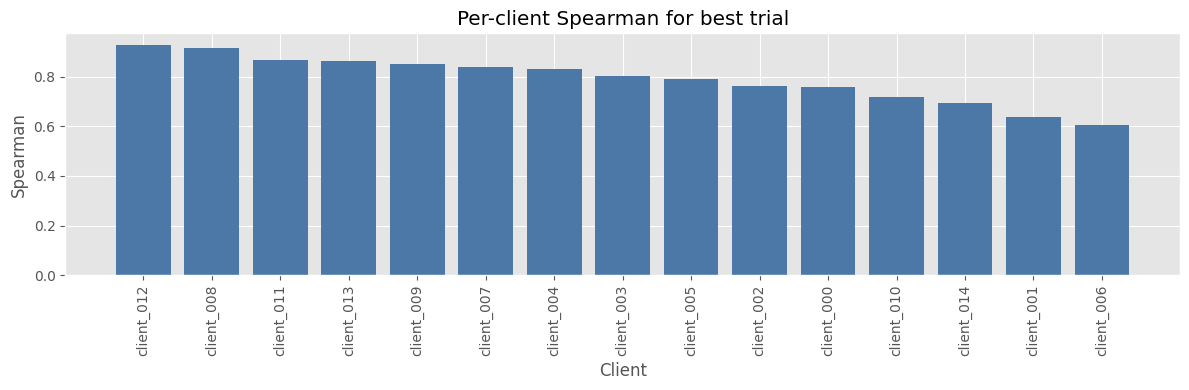

In [8]:
best_client_df = (
    pd.Series(best_row["client_spearman"], name="spearman")
    .sort_values(ascending=False)
    .rename_axis("client_id")
    .reset_index()
)
display(best_client_df)

fig, ax = plt.subplots(figsize=(12, 4))
ax.bar(best_client_df["client_id"], best_client_df["spearman"], color="#4C78A8")
ax.set_title("Per-client Spearman for best trial")
ax.set_ylabel("Spearman")
ax.set_xlabel("Client")
ax.tick_params(axis="x", rotation=90)
plt.tight_layout()
plt.show()


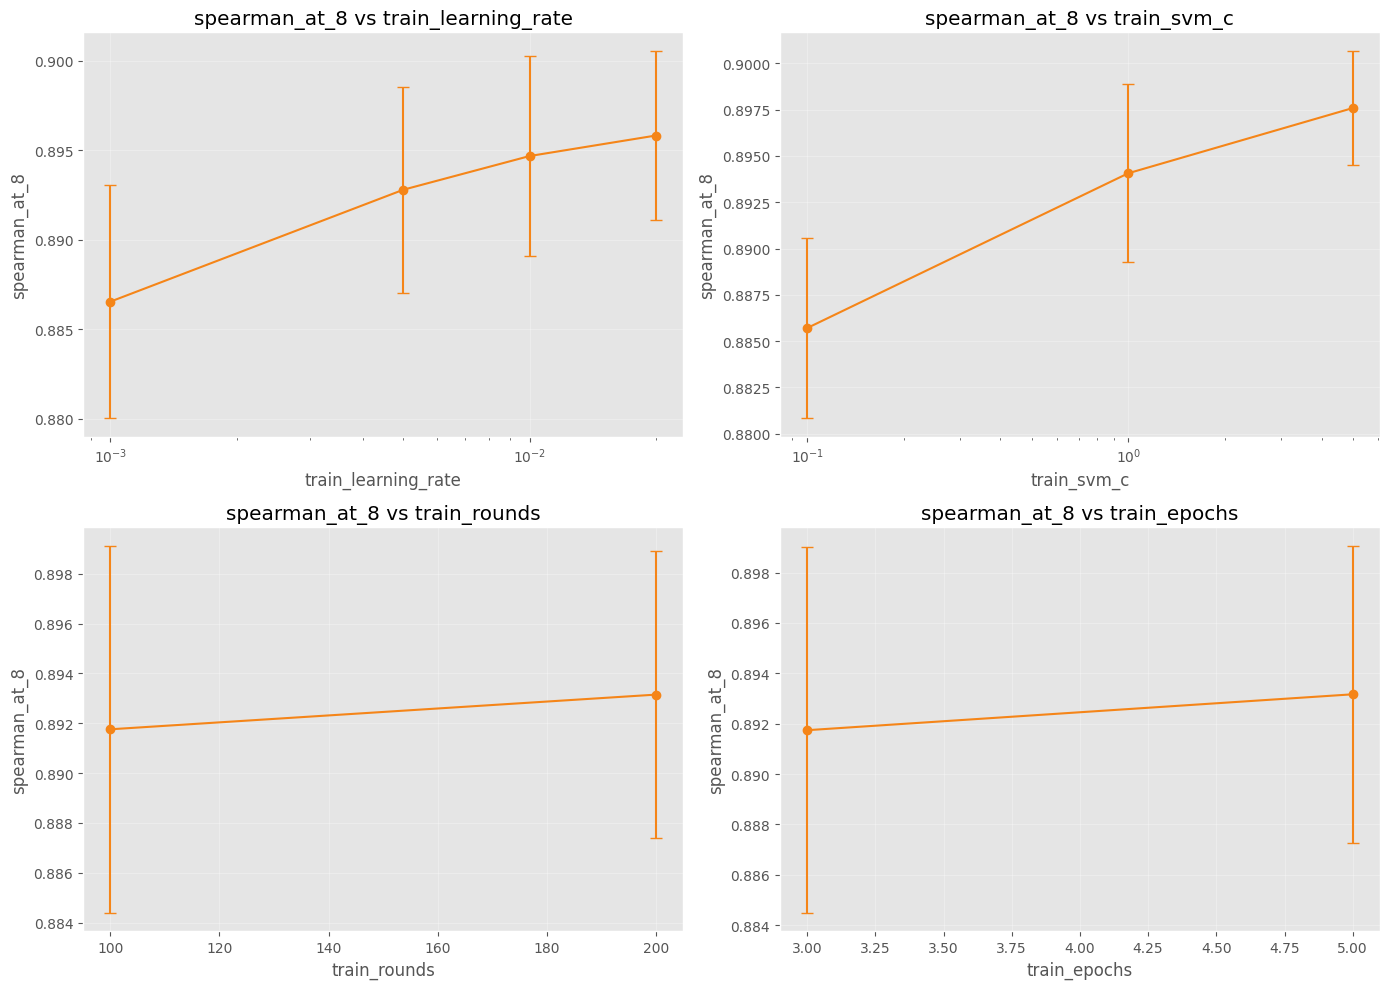

In [9]:
def plot_effect(ax, frame: pd.DataFrame, column: str, metric: str, log_x: bool = False) -> None:
    grouped = (
        frame.groupby(column, dropna=False)[metric]
        .agg(["mean", "std", "count"])
        .reset_index()
        .sort_values(column)
    )
    x = grouped[column].to_numpy()
    y = grouped["mean"].to_numpy()
    yerr = grouped["std"].fillna(0.0).to_numpy()

    ax.errorbar(x, y, yerr=yerr, fmt="-o", capsize=4, color="#F58518")
    ax.set_title(f"{metric} vs {column}")
    ax.set_xlabel(column)
    ax.set_ylabel(metric)
    if log_x:
        ax.set_xscale("log")
    ax.grid(True, alpha=0.3)


fig, axes = plt.subplots(2, 2, figsize=(14, 10))
plot_effect(axes[0, 0], df, "train_learning_rate", PRIMARY_METRIC, log_x=True)
plot_effect(axes[0, 1], df, "train_svm_c", PRIMARY_METRIC, log_x=True)
plot_effect(axes[1, 0], df, "train_rounds", PRIMARY_METRIC)
plot_effect(axes[1, 1], df, "train_epochs", PRIMARY_METRIC)
plt.tight_layout()
plt.show()


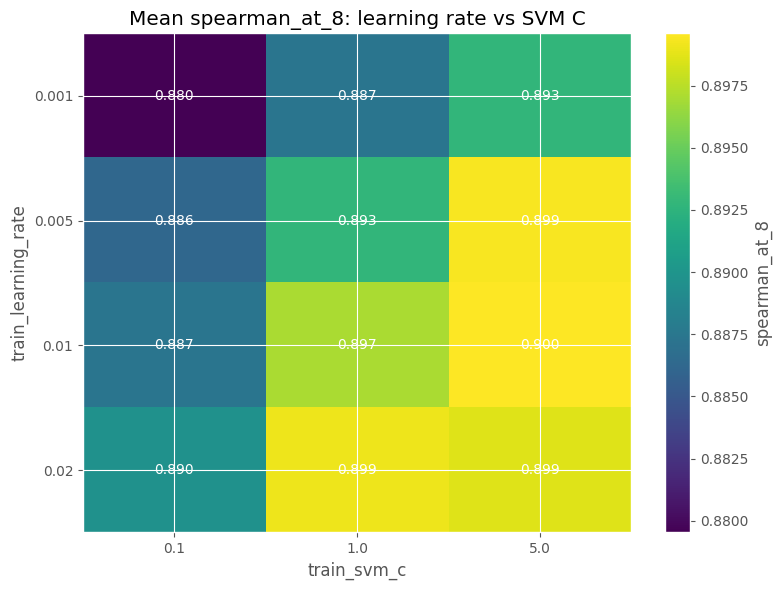

In [10]:
heatmap_df = (
    df.groupby(["train_learning_rate", "train_svm_c"])[PRIMARY_METRIC]
    .mean()
    .unstack("train_svm_c")
    .sort_index()
)

fig, ax = plt.subplots(figsize=(8, 6))
im = ax.imshow(heatmap_df.to_numpy(), aspect="auto", cmap="viridis")
ax.set_title(f"Mean {PRIMARY_METRIC}: learning rate vs SVM C")
ax.set_xlabel("train_svm_c")
ax.set_ylabel("train_learning_rate")
ax.set_xticks(range(len(heatmap_df.columns)))
ax.set_xticklabels([str(col) for col in heatmap_df.columns])
ax.set_yticks(range(len(heatmap_df.index)))
ax.set_yticklabels([str(idx) for idx in heatmap_df.index])

for row_idx in range(heatmap_df.shape[0]):
    for col_idx in range(heatmap_df.shape[1]):
        value = heatmap_df.iloc[row_idx, col_idx]
        if pd.notna(value):
            ax.text(col_idx, row_idx, f"{value:.3f}", ha="center", va="center", color="white")

fig.colorbar(im, ax=ax, label=PRIMARY_METRIC)
plt.tight_layout()
plt.show()


In [11]:
grouped_rankings = {
    "learning_rate": df.groupby("train_learning_rate")[PRIMARY_METRIC].mean().sort_values(ascending=False),
    "svm_c": df.groupby("train_svm_c")[PRIMARY_METRIC].mean().sort_values(ascending=False),
    "rounds": df.groupby("train_rounds")[PRIMARY_METRIC].mean().sort_values(ascending=False),
    "epochs": df.groupby("train_epochs")[PRIMARY_METRIC].mean().sort_values(ascending=False),
}

for name, series in grouped_rankings.items():
    print(f"\nBest {name} values by mean {PRIMARY_METRIC}")
    display(series.to_frame("mean_metric"))



Best learning_rate values by mean spearman_at_8


,mean_metric
train_learning_rate,
0.020,0.895818
0.010,0.894673
0.005,0.892790
0.001,0.886533



Best svm_c values by mean spearman_at_8


,mean_metric
train_svm_c,
5.0,0.897589
1.0,0.894068
0.1,0.885704



Best rounds values by mean spearman_at_8


,mean_metric
train_rounds,
200,0.893149
100,0.891758



Best epochs values by mean spearman_at_8


,mean_metric
train_epochs,
5,0.893166
3,0.891741
